Build a Basic Chatbot (Graph API)

In [1]:
from typing import Annotated,TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages  # it is used to add(append) the answer or messages to the variable that we define in the state insteading of replacing it
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
class State(TypedDict):
    #""" Messages have the type 'list'. 
    #The add_messages function in the annotation defines how this state should be updated
    #(in this case, it appends messages to the list , rather than overwritting them)"""
    messages:Annotated[list,add_messages]

In [3]:
from langchain_groq import ChatGroq
model=ChatGroq(model='llama-3.3-70b-versatile')
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002695956D7B0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002695956D6C0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [4]:
## Node Functionality
def chatbot(state:State):   #  -----------> Node
    return{"messages":[model.invoke(state['messages'])]}

In [5]:
graph_builder=StateGraph(state_schema=State)

# Adding node
graph_builder.add_node('llmchatbot',chatbot)

# Adding Edges
graph_builder.add_edge(START,'llmchatbot')
graph_builder.add_edge('llmchatbot',END)

# Compile the graph
graph=graph_builder.compile()

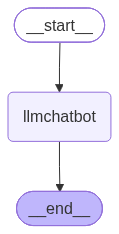

In [6]:
# Visualize the Grpah
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [7]:
graph.invoke({'messages':'Hi'})

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='5f02040f-61b2-41fe-8fd6-fcd951851cd9'),
  AIMessage(content="It's nice to meet you. Is there something I can help you with, or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 36, 'total_tokens': 60, 'completion_time': 0.05985754, 'completion_tokens_details': None, 'prompt_time': 0.001364417, 'prompt_tokens_details': None, 'queue_time': 0.161298272, 'total_time': 0.061221957}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8a22-02b0-7a63-a923-c9248af2b928-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 24, 'total_tokens': 60})]}

In [8]:
for event in graph.stream({'messages':'Hi How are you'}):
    #print(event)
    for value in event.values():
        print(value)

{'messages': [AIMessage(content="I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm always happy to chat and help with any questions or topics you'd like to discuss. How about you? How's your day going so far?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 39, 'total_tokens': 100, 'completion_time': 0.10338594, 'completion_tokens_details': None, 'prompt_time': 0.003481912, 'prompt_tokens_details': None, 'queue_time': 0.054146757, 'total_time': 0.106867852}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8a22-04b9-7733-a099-0bafde205c78-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 39, 'output_tokens': 61, 'total_tokens': 100})]}


Chatbot with Tools

In [9]:
from langchain_tavily import TavilySearch
tool=TavilySearch(max_results=2)
tools=[tool]
tool.invoke('what is Langgraph')

{'query': 'what is Langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the navigat

In [10]:
##Custom Function
def multiply(a:int,b:int)->int:
    """
    Multiply two numbers.

    Args:
        a: First number.
        b: Second number.

    Returns:
        Product of the two numbers.
    """
    return a*b

In [11]:
tools=[tool,multiply]

In [12]:
model_with_tools=model.bind_tools(tools=tools)
model_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002695956D7B0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002695956D6C0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search 

In [13]:
# StateGraph
from langgraph.prebuilt import ToolNode,tools_condition

## Node Defination
def tool_calling_llm(state:State):
    return{'messages':[model_with_tools.invoke(state['messages'])]}

# Graph
builder=StateGraph(state_schema=State)
builder.add_node('tool_calling_llm',tool_calling_llm)
builder.add_node('tools',ToolNode(tools=tools))

# Add Edges
builder.add_edge(START,'tool_calling_llm')
builder.add_conditional_edges(
    'tool_calling_llm',
    #If the latest message (result) from assistant is a tool call -> tools_condition routes to tools(ToolNode)
    #If the latest message (result) frpm assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge('tools',END)

# compile the graph

graph=builder.compile()

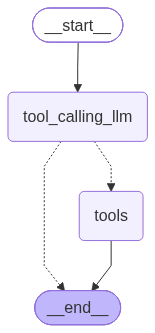

In [14]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
response=graph.invoke({'messages':'What is latest news in India'})
response

{'messages': [HumanMessage(content='What is latest news in India', additional_kwargs={}, response_metadata={}, id='d04bc90d-4a53-4766-9562-970f38a757e3'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'p1628g8pn', 'function': {'arguments': '{"query":"latest news in India","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 1749, 'total_tokens': 1774, 'completion_time': 0.092567638, 'completion_tokens_details': None, 'prompt_time': 0.472283078, 'prompt_tokens_details': None, 'queue_time': 0.16179206, 'total_time': 0.564850716}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8a22-0d47-7183-af74-b1de9c62aeb7-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'latest news in India', 'topic': 'news'}, 'id': 'p1628g8pn', '

In [16]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is latest news in India
================================== Ai Message ==================================
Tool Calls:
  tavily_search (p1628g8pn)
 Call ID: p1628g8pn
  Args:
    query: latest news in India
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest news in India", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.reuters.com/world/india/india-youth-group-says-protest-continue-after-delhi-clashes-injure-180-2026-07-21/", "title": "India youth group says will not march again because police will 'hurt youth' - Reuters", "score": 0.74004334, "published_date": "Tue, 21 Jul 2026 04:30:12 GMT", "content": "## Browse World. ## Browse Business. Item 1 of 8 Tear gas spreads around protesters as supporters of India's Cockroach Janta Party demonstrate on the opening day of the Ind

In [17]:
response2=graph.invoke({'messages':'What is 100 multiplied by 200'})
response2

{'messages': [HumanMessage(content='What is 100 multiplied by 200', additional_kwargs={}, response_metadata={}, id='9221abc6-a620-413a-9c09-3a9577f30db5'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'gphsjxa1z', 'function': {'arguments': '{"a":100,"b":200}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1751, 'total_tokens': 1770, 'completion_time': 0.058224521, 'completion_tokens_details': None, 'prompt_time': 0.419162554, 'prompt_tokens_details': None, 'queue_time': 0.054072439, 'total_time': 0.477387075}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8a22-1684-7302-acf2-208f448eede7-0', tool_calls=[{'name': 'multiply', 'args': {'a': 100, 'b': 200}, 'id': 'gphsjxa1z', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_

In [18]:
for m in response2['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 100 multiplied by 200
================================== Ai Message ==================================
Tool Calls:
  multiply (gphsjxa1z)
 Call ID: gphsjxa1z
  Args:
    a: 100
    b: 200
================================= Tool Message =================================
Name: multiply

20000


In [19]:
response3=graph.invoke({'messages':'What is latest Indian news and latest sports news'})
response3

{'messages': [HumanMessage(content='What is latest Indian news and latest sports news', additional_kwargs={}, response_metadata={}, id='0a1e2206-dc66-4142-b841-06e9f7e7e5fd'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'grvckc560', 'function': {'arguments': '{"query":"latest Indian news","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': 'v2z0q3p9v', 'function': {'arguments': '{"query":"latest sports news","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 1752, 'total_tokens': 1799, 'completion_time': 0.127136187, 'completion_tokens_details': None, 'prompt_time': 0.206851147, 'prompt_tokens_details': None, 'queue_time': 0.386284675, 'total_time': 0.333987334}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_ru

In [20]:
for m in response3['messages']:
    m.pretty_print()

================================ Human Message =================================

What is latest Indian news and latest sports news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (grvckc560)
 Call ID: grvckc560
  Args:
    query: latest Indian news
    topic: news
  tavily_search (v2z0q3p9v)
 Call ID: v2z0q3p9v
  Args:
    query: latest sports news
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest Indian news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.reuters.com/world/india/india-court-allows-activist-wangchuk-be-moved-private-hospital-legal-website-2026-07-21/", "title": "India court allows activist Wangchuk to be moved to private hospital, legal website says - Reuters", "score": 0.64020914, "published_date": "Tue, 21 Jul 2026 08:07:14 GMT", "content": "Exclusive news, data and analytics 

In [21]:
# Even though the graph is able to answer 2 questions 
# sometimes it may fail and end up givig the output for only one question output
# Solution: we can use the ReAct Agent Architecture

ReAct Agent Architecture

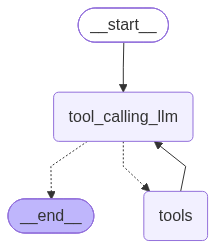

In [22]:
# StateGraph
from langgraph.prebuilt import ToolNode,tools_condition

## Node Defination
def tool_calling_llm(state:State):
    return{'messages':[model_with_tools.invoke(state['messages'])]}

# Graph
builder=StateGraph(state_schema=State)
builder.add_node('tool_calling_llm',tool_calling_llm)
builder.add_node('tools',ToolNode(tools=tools))

# Add Edges
builder.add_edge(START,'tool_calling_llm')
builder.add_conditional_edges(
    'tool_calling_llm',
    #If the latest message (result) from assistant is a tool call -> tools_condition routes to tools(ToolNode)
    #If the latest message (result) frpm assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge('tools','tool_calling_llm')

# compile the graph

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
response4=graph.invoke({'messages':'What is latest Indian news and then multiply 5 by 2'})
for m in response4['messages']:
    m.pretty_print()

================================ Human Message =================================

What is latest Indian news and then multiply 5 by 2
================================== Ai Message ==================================
Tool Calls:
  tavily_search (1kcd1jb9w)
 Call ID: 1kcd1jb9w
  Args:
    query: latest Indian news
    topic: news
  multiply (f9keasfwd)
 Call ID: f9keasfwd
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: tavily_search

{"query": "latest Indian news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.reuters.com/world/india/india-court-allows-activist-wangchuk-be-moved-private-hospital-legal-website-2026-07-21/", "title": "India court allows activist Wangchuk to be moved to private hospital, legal website says - Reuters", "score": 0.64020914, "published_date": "Tue, 21 Jul 2026 08:07:14 GMT", "content": "Exclusive news, data and analytics for financial market profession

Adding Memory in Agentic Graph

In [24]:
# Checkpointer=InMemorySaver()
# What it does is it saves the state after the answer from agent and whenever u ask new question(invoke) to agent first it loads the latest state and merges ur req into it and pass it to agent

In [25]:
graph.invoke({'messages':'Hello , My name is Rishi'})

{'messages': [HumanMessage(content='Hello , My name is Rishi', additional_kwargs={}, response_metadata={}, id='04512161-eb73-421b-920d-fb795596f853'),
  AIMessage(content="Hello Rishi! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1750, 'total_tokens': 1777, 'completion_time': 0.088111636, 'completion_tokens_details': None, 'prompt_time': 0.297115557, 'prompt_tokens_details': None, 'queue_time': 0.050068279, 'total_time': 0.385227193}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8a22-38fc-7251-8dbc-555e5ab85138-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1750, 'output_tokens': 27, 'total_tokens': 1777})]}

In [26]:
graph.invoke({'messages':'Whats my name?'})

{'messages': [HumanMessage(content='Whats my name?', additional_kwargs={}, response_metadata={}, id='5d12afcc-6e6c-43d7-9c6d-53a381c20cef'),
  AIMessage(content="I don't have any information about your name. This conversation just started, and I don't have any prior knowledge about you. If you'd like to share your name, I'd be happy to chat with you!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 1747, 'total_tokens': 1792, 'completion_time': 0.124376177, 'completion_tokens_details': None, 'prompt_time': 0.229188456, 'prompt_tokens_details': None, 'queue_time': 0.160991519, 'total_time': 0.353564633}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8a22-3b66-71f3-a265-0dbbdd2dfafa-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1747, 'output_tokens': 45, 'total_t

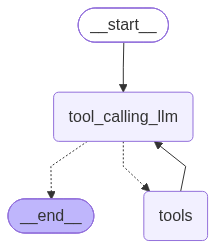

In [27]:
# StateGraph
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.checkpoint.memory import InMemorySaver
memory =InMemorySaver()

## Node Defination
def tool_calling_llm(state:State):
    return{'messages':[model_with_tools.invoke(state['messages'])]}

# Graph
builder=StateGraph(state_schema=State)
builder.add_node('tool_calling_llm',tool_calling_llm)
builder.add_node('tools',ToolNode(tools=tools))

# Add Edges
builder.add_edge(START,'tool_calling_llm')
builder.add_conditional_edges(
    'tool_calling_llm',
    #If the latest message (result) from assistant is a tool call -> tools_condition routes to tools(ToolNode)
    #If the latest message (result) frpm assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge('tools','tool_calling_llm')

# compile the graph

graph=builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
config={'configurable':{'thread_id':'chat1'}}  # ------> thread_id is like session id
graph.invoke({'messages':'Hello , My name is Rishi'},config=config)

{'messages': [HumanMessage(content='Hello , My name is Rishi', additional_kwargs={}, response_metadata={}, id='7d0608c2-0acd-4f95-8a89-45ac0c0ba51a'),
  AIMessage(content="Hello Rishi! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1750, 'total_tokens': 1777, 'completion_time': 0.081770882, 'completion_tokens_details': None, 'prompt_time': 0.172458443, 'prompt_tokens_details': None, 'queue_time': 0.161353073, 'total_time': 0.254229325}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8a22-40e3-7771-8062-064715600181-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1750, 'output_tokens': 27, 'total_tokens': 1777})]}

In [29]:
graph.invoke({'messages':'Whats my name?'},config=config)

{'messages': [HumanMessage(content='Hello , My name is Rishi', additional_kwargs={}, response_metadata={}, id='7d0608c2-0acd-4f95-8a89-45ac0c0ba51a'),
  AIMessage(content="Hello Rishi! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1750, 'total_tokens': 1777, 'completion_time': 0.081770882, 'completion_tokens_details': None, 'prompt_time': 0.172458443, 'prompt_tokens_details': None, 'queue_time': 0.161353073, 'total_time': 0.254229325}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8a22-40e3-7771-8062-064715600181-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1750, 'output_tokens': 27, 'total_tokens': 1777}),
  HumanMessage(content='Whats my name?', additional_kwargs={}, 

#### Streamming

In [33]:
def superbot(state:State):
    return {'messages':[model.invoke(state['messages'])]}

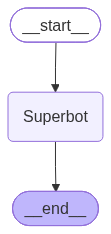

In [35]:
graph_builder=StateGraph(State)

#node
graph_builder.add_node('Superbot',superbot)

#Edges
graph_builder.add_edge(START,'Superbot')
graph_builder.add_edge('Superbot',END)

graph=graph_builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [37]:
# Invoke
config={'configurable':{'thread_id':'3'}}
graph.invoke({'messages':'Hi,My name is Rishi and i love badminton'},config)

{'messages': [HumanMessage(content='Hi,My name is Rishi and i love badminton', additional_kwargs={}, response_metadata={}, id='07a8d1ea-d08b-42aa-aa30-0e0c4e4df56e'),
  AIMessage(content="Nice to meet you, Rishi! Badminton is an exciting sport, isn't it? The speed, agility, and strategy involved make it a thrilling game to play and watch. Do you play badminton regularly or just for fun? Are you a fan of any particular badminton player or tournament?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 48, 'total_tokens': 113, 'completion_time': 0.184798301, 'completion_tokens_details': None, 'prompt_time': 0.002174002, 'prompt_tokens_details': None, 'queue_time': 0.049970073, 'total_time': 0.186972303}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8a3b-1fb6-7732-83fb-d0eb98d989a2-0', tool_ca

In [39]:
onfig={'configurable':{'thread_id':'4'}}
for chunk in graph.stream({'messages':'Hi,My name is Rishi and i love badminton'},config,stream_mode='updates'):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="Hi Rishi, nice to meet you! It's great that you love badminton! What is it about badminton that you enjoy the most? Is it the fast-paced gameplay, the thrill of smashing a shot, or the strategy involved in outmaneuvering your opponents? Do you have a favorite badminton player or team that you like to watch or follow?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 135, 'total_tokens': 214, 'completion_time': 0.227514198, 'completion_tokens_details': None, 'prompt_time': 0.007149438, 'prompt_tokens_details': None, 'queue_time': 0.16063651, 'total_time': 0.234663636}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8a3d-054a-7dc0-9919-201abc6cabcd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 135, 'output_tokens': 79, 

In [40]:
onfig={'configurable':{'thread_id':'4'}}
for chunk in graph.stream({'messages':'I also love cricket'},config,stream_mode='values'):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Rishi and i love badminton', additional_kwargs={}, response_metadata={}, id='07a8d1ea-d08b-42aa-aa30-0e0c4e4df56e'), AIMessage(content="Nice to meet you, Rishi! Badminton is an exciting sport, isn't it? The speed, agility, and strategy involved make it a thrilling game to play and watch. Do you play badminton regularly or just for fun? Are you a fan of any particular badminton player or tournament?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 48, 'total_tokens': 113, 'completion_time': 0.184798301, 'completion_tokens_details': None, 'prompt_time': 0.002174002, 'prompt_tokens_details': None, 'queue_time': 0.049970073, 'total_time': 0.186972303}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8a3b-1fb6-7732-83fb-d0eb98d989a2-0', tool_call

In [41]:
# If u use astream more detailed info